In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

I don't know why, but downloading the file directly using this notebook didn't work. I had to manually download and save it.

In [ ]:
data = "https://github.com/alexeygrigorev/mlbookcamp-code/blob/master/chapter-02-car-price/data.csv"
! wget $data

In [15]:
df = pd.read_csv("C:\\Users\\Gigabyte\\OneDrive\\Documentos\\QuantumControl\\Road_to_alternatives\\DataFiles\\data_cars_linregr.csv")

In [16]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [17]:
df.columns

Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP'],
      dtype='object')

In [19]:
df.shape

(11914, 16)

In [18]:
df.dtypes

Make                  object
Model                 object
Year                   int64
Engine Fuel Type      object
Engine HP            float64
Engine Cylinders     float64
Transmission Type     object
Driven_Wheels         object
Number of Doors      float64
Market Category       object
Vehicle Size          object
Vehicle Style         object
highway MPG            int64
city mpg               int64
Popularity             int64
MSRP                   int64
dtype: object

For data manipulation purposes, it is common to unify the format of column names and string variables. Tipically, we set all strings to lower case and spaces to underscores. Use the "apply()" function to operate over an entire data frame. If applying to just a column, or the column names themselves, apply the function directly to it.

In [32]:
df[df.columns[df.dtypes == 'object']] = df[df.columns[df.dtypes == 'object']].apply(lambda x: x.str.lower().str.replace(' ', '_'))
df.rename(columns=lambda x: x.lower().replace(' ', '_'), inplace=True)
#df.columns[df.dtypes == 'object'] = df.columns[df.dtypes == 'object'].str.lower().str.replace(' ', '_')


Now, visualize some data using histograms. Here we are particularly interested in the price of the cars.

In [34]:
import seaborn as sns

<Axes: xlabel='msrp', ylabel='Count'>

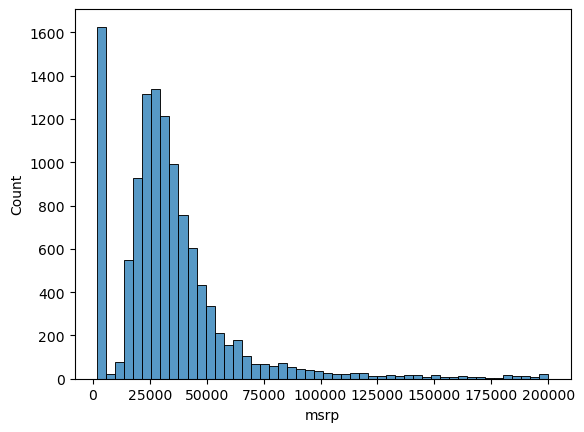

In [46]:
sns.histplot(data=df, x='msrp', bins=50, binrange=(df.msrp.min()-1, 2.e5))

Since there are orders of magnitude of difference in the prices of the cars, we better use logscale.

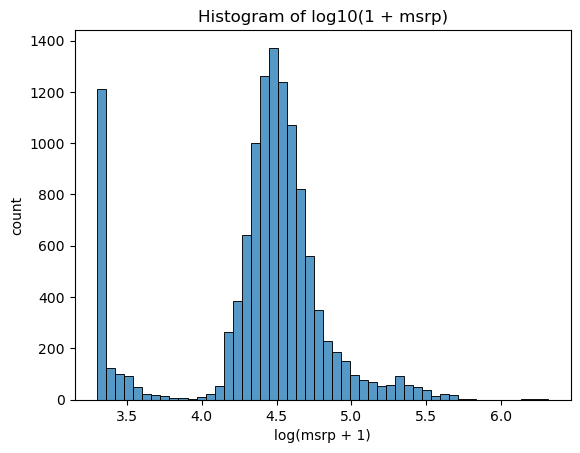

In [53]:
logprice = np.log10(1 + df.msrp)
ax = sns.histplot(logprice, bins=50, )
ax.set(xlabel='log(msrp + 1)', ylabel='count', title='Histogram of log10(1 + msrp)');

To predict the price of a car from its parameters (year, fuel efficiency, etc), we propose a multilinear model, i.e., we assume that the price depends linearly on all these variables. First, we have to isolate the numerical variables. Then, we need to prepare these data to feed a training algorithm (remove Nan's and outliers). Don't forget to split the data set into a training and a validation subsets.

In [55]:
df[df.columns[df.dtypes != 'object']].dtypes

year                  int64
engine_hp           float64
engine_cylinders    float64
number_of_doors     float64
highway_mpg           int64
city_mpg              int64
popularity            int64
msrp                  int64
dtype: object

In [63]:
numframe = df[df.columns[df.dtypes != 'object']]
numframe.isna().sum()

year                 0
engine_hp           69
engine_cylinders    30
number_of_doors      6
highway_mpg          0
city_mpg             0
popularity           0
msrp                 0
dtype: int64

Fill the NaN values with some numbers. Commom options are filling with zeros, and with the average of the remaining values.

In [66]:
numframe = numframe.fillna(numframe.mean()) 

In [68]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

Split the dataset and train the model. drop() eliminates one or more specific columns.

In [69]:
train, test = train_test_split(numframe, test_size=0.25)
LinearRegressionModel = LinearRegression().fit(train.drop(columns=['msrp']), train.msrp)

Validate with the test dataset.

In [76]:
type(train)

pandas.core.frame.DataFrame